**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ----------------------------------------------------------
# Define base dataset directory
# This is the folder that contains one or more datasets
# ----------------------------------------------------------

import os

base_path = "/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data"

if not os.path.exists(base_path):
    raise ValueError(f"Base path not found: {base_path}")

print("Base path verified.")

ValueError: Base path not found: /content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data

In [ ]:
# ----------------------------------------------------------
# Detect all dataset folders inside base directory
# ----------------------------------------------------------

datasets = [
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
]

if len(datasets) == 0:
    raise ValueError("No dataset folders found.")

print("Available datasets:")
for i, d in enumerate(datasets):
    print(f"{i} → {d}")

Available datasets:
0 → DPDDataset
1 → DPDDataset_face_224


In [ ]:
# ----------------------------------------------------------
# Select dataset by index
# ----------------------------------------------------------

dataset_index = int(input("Enter dataset index to use: "))

if dataset_index < 0 or dataset_index >= len(datasets):
    raise ValueError("Invalid dataset index.")

selected_dataset = datasets[dataset_index]
data_path = os.path.join(base_path, selected_dataset)

print("Selected dataset:", selected_dataset)
print("Dataset path:", data_path)

Enter dataset index to use: 0
Selected dataset: DPDDataset
Dataset path: /content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset


In [ ]:
# ----------------------------------------------------------
# Extract zip files safely (only if not extracted)
# ----------------------------------------------------------

import zipfile

for item in os.listdir(data_path):

    if item.lower().endswith(".zip"):

        zip_path = os.path.join(data_path, item)
        extract_folder = os.path.join(data_path, item.replace(".zip", ""))

        if os.path.exists(extract_folder) and len(os.listdir(extract_folder)) > 0:
            print(f"{item} already extracted.")
        else:
            print(f"Extracting {item}...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(data_path)

print("ZIP extraction complete.")

NonDrowsy.zip already extracted.
Drowsy.zip already extracted.
ZIP extraction complete.


In [ ]:
# ----------------------------------------------------------
# Detect valid class folders only
# Excludes system folders like __MACOSX
# ----------------------------------------------------------

classes = []

for folder in os.listdir(data_path):

    folder_path = os.path.join(data_path, folder)

    # Condition 1: Must be directory
    if not os.path.isdir(folder_path):
        continue

    # Condition 2: Ignore hidden/system folders
    if folder.startswith("_") or folder.startswith("."):
        continue

    # Condition 3: Must contain at least 1 image
    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(image_files) > 0:
        classes.append(folder)

print("Valid detected classes:")
for c in classes:
    print("-", c)

Valid detected classes:
- NonDrowsy
- Drowsy


In [ ]:
# ----------------------------------------------------------
# Count number of images per class
# ----------------------------------------------------------

for class_name in classes:
    class_path = os.path.join(data_path, class_name)
    image_count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    print(f"{class_name}: {image_count} images")

NonDrowsy: 4560 images
Drowsy: 4560 images


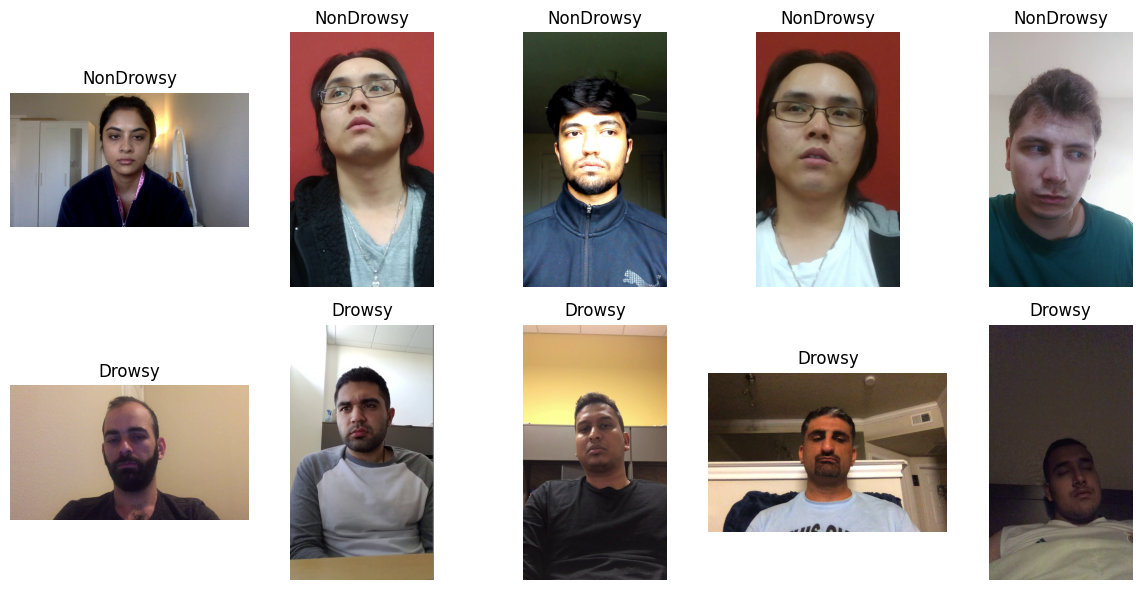

In [ ]:
# ----------------------------------------------------------
# Visualize random samples from each class
# ----------------------------------------------------------

import random
import matplotlib.pyplot as plt
from PIL import Image

samples_per_class = 5  # number of images to show per class

plt.figure(figsize=(12, 6))

plot_index = 1

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_samples = random.sample(image_files, samples_per_class)

    for file in random_samples:
        file_path = os.path.join(class_path, file)

        img = Image.open(file_path)

        plt.subplot(len(classes), samples_per_class, plot_index)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------
# Fast integrity check: 100 random images per class
# ----------------------------------------------------------

import random
from PIL import Image

corrupted_images = []
sample_size = 10

for class_name in classes:

    class_path = os.path.join(data_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Random sample (safe even if less than 10 images)
    sampled_files = random.sample(image_files, min(sample_size, len(image_files)))

    for file in sampled_files:
        file_path = os.path.join(class_path, file)

        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            corrupted_images.append(file_path)

print("Total images checked:", sample_size * len(classes))
print("Corrupted images found:", len(corrupted_images))

Total images checked: 20
Corrupted images found: 0


In [ ]:
# ----------------------------------------------------------
# Analyze image size distribution
# ----------------------------------------------------------

from PIL import Image
from collections import Counter
import os

image_sizes = []

for class_name in classes:
    class_path = os.path.join(data_path, class_name)

    for file in os.listdir(class_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            file_path = os.path.join(class_path, file)

            with Image.open(file_path) as img:
                image_sizes.append(img.size)  # (width, height)

# Count unique resolutions
size_counts = Counter(image_sizes)

print("Number of unique image resolutions:", len(size_counts))

# Show top 10 most common sizes
print("\nTop 10 most common resolutions:")
for size, count in size_counts.most_common(10):
    print(f"{size} → {count} images")

Number of unique image resolutions: 8

Top 10 most common resolutions:
(1080, 1920) → 3737 images
(1080, 720) → 1789 images
(1920, 1080) → 1184 images
(720, 1280) → 752 images
(640, 480) → 730 images
(1280, 720) → 559 images
(480, 853) → 186 images
(896, 592) → 183 images


Face Detection Library (MTCNN)

In [ ]:
# Install MTCNN for face detection
!pip install mtcnn

In [ ]:
# Core libraries
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Face detection
from mtcnn import MTCNN

# Initialize face detector
detector = MTCNN()

In [ ]:
classes

['NonDrowsy', 'Drowsy']

In [ ]:
data_path

'/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset'

In [ ]:
# Function to detect and crop face few images
def detect_and_crop_face(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if len(results) > 0:
        x, y, w, h = results[0]['box']

        # Ensure bounding box is valid
        x, y = max(0, x), max(0, y)

        face = img_rgb[y:y+h, x:x+w]
        return face
    else:
        return None

Visualize Face Cropping Results

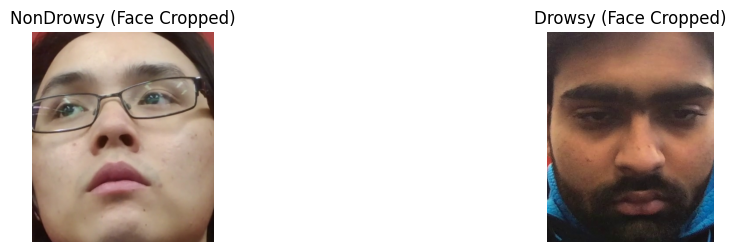

In [ ]:
import random

plt.figure(figsize=(12, 6))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(data_path, class_name)
    image_name = random.choice(os.listdir(class_folder))
    image_path = os.path.join(class_folder, image_name)

    cropped_face = detect_and_crop_face(image_path)

    plt.subplot(2, 2, i+1)

    if cropped_face is not None:
        plt.imshow(cropped_face)
        plt.title(f"{class_name} (Face Cropped)")
    else:
        plt.title(f"{class_name} (No Face Detected)")

    plt.axis("off")

plt.show()

In [ ]:
# ----------------------------------------------------------
# Estimate face detection success rate using random sampling
# ----------------------------------------------------------

import random

sample_size = 100  # statistically sufficient for estimation

all_image_paths = []

for class_name in classes:
    class_folder = os.path.join(data_path, class_name)

    for file in os.listdir(class_folder):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            all_image_paths.append(os.path.join(class_folder, file))

# Randomly sample images
sampled_images = random.sample(all_image_paths, min(sample_size, len(all_image_paths)))

faces_detected = 0

for image_path in sampled_images:
    face = detect_and_crop_face(image_path)
    if face is not None:
        faces_detected += 1

detection_rate = (faces_detected / len(sampled_images)) * 100

print("Sample size:", len(sampled_images))
print("Faces detected:", faces_detected)
print("Estimated detection rate:", round(detection_rate, 2), "%")

Sample size: 100
Faces detected: 100
Estimated detection rate: 100.0 %


In [ ]:
base_path

'/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data'

In [ ]:
# ----------------------------------------------------------
# Dynamically detect raw dataset (exclude processed folders)
# ----------------------------------------------------------

import os

# base_path is already defined earlier

# Detect available datasets (exclude processed ones)
datasets = [
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
    and not d.endswith("_face_224")
    and not d.startswith("__")
]

print("Available raw datasets:")
for i, d in enumerate(datasets):
    print(f"{i} → {d}")

# Select first dataset dynamically (can change later)
selected_dataset = datasets[0]

raw_base_path = os.path.join(base_path, selected_dataset)

# Define processed path automatically
processed_root = os.path.join(base_path, selected_dataset + "_face_224")

os.makedirs(processed_root, exist_ok=True)

# Detect class folders dynamically
classes = [
    folder for folder in os.listdir(raw_base_path)
    if os.path.isdir(os.path.join(raw_base_path, folder))
    and not folder.startswith("__")
]

print("\nUsing dataset:", selected_dataset)
print("Detected classes:")
for c in classes:
    print("-", c)

Available raw datasets:
0 → DPDDataset

Using dataset: DPDDataset
Detected classes:
- NonDrowsy
- Drowsy


In [ ]:
# ----------------------------------------------------------
# Face detection + padding + resize
# ----------------------------------------------------------

import cv2
import numpy as np

def detect_crop_resize(image_path, size=224, padding=0.2):
    img = cv2.imread(image_path)

    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if len(results) == 0:
        return None

    x, y, w, h = results[0]['box']
    x, y = max(0, x), max(0, y)

    pad_w = int(w * padding)
    pad_h = int(h * padding)

    x1 = max(0, x - pad_w)
    y1 = max(0, y - pad_h)
    x2 = min(img_rgb.shape[1], x + w + pad_w)
    y2 = min(img_rgb.shape[0], y + h + pad_h)

    face = img_rgb[y1:y2, x1:x2]

    if face.size == 0:
        return None

    face_resized = cv2.resize(face, (size, size))

    return face_resized

In [ ]:
import os

processed_root = os.path.join(
    os.path.dirname(data_path),
    "DPDDataset_face_224"
)

os.makedirs(processed_root, exist_ok=True)

print("Processed dataset will be saved to:")
print(processed_root)

Processed dataset will be saved to:
/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset_face_224


In [ ]:
print("data_path:")
print(data_path)

print("\nFolders inside data_path:")
print(os.listdir(data_path))

data_path:
/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset

Folders inside data_path:
['NonDrowsy.zip', 'Drowsy.zip', 'NonDrowsy', 'Drowsy']


In [ ]:
for class_name in classes:
  print(class_name)

NonDrowsy
Drowsy


In [ ]:
# ----------------------------------------------------------
# Process dataset: crop faces + resize (224x224) + save
# ----------------------------------------------------------

from tqdm import tqdm
import cv2
import os

failed_images = []

for class_name in classes:

    raw_class_path = os.path.join(data_path, class_name)
    processed_class_path = os.path.join(processed_root, class_name)

    os.makedirs(processed_class_path, exist_ok=True)

    image_files = [
        f for f in os.listdir(raw_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"\nProcessing class: {class_name}")

    for file in tqdm(image_files):

        input_path = os.path.join(raw_class_path, file)
        output_path = os.path.join(processed_class_path, file)

        if os.path.exists(output_path):
            continue

        face = detect_crop_resize(input_path)

        if face is not None:
            face_bgr = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, face_bgr)
        else:
            failed_images.append(input_path)

print("\nProcessing complete.")
print("Total failed detections:", len(failed_images))


Processing class: NonDrowsy


100%|██████████| 4560/4560 [00:14<00:00, 316.02it/s] 



Processing class: Drowsy


100%|██████████| 4560/4560 [01:59<00:00, 38.10it/s]


Processing complete.
Total failed detections: 43


In [ ]:
# ----------------------------------------------------------
# Verify processed dataset integrity
# ----------------------------------------------------------

for class_name in classes:

    raw_class_path = os.path.join(data_path, class_name)
    processed_class_path = os.path.join(processed_root, class_name)

    raw_count = len([
        f for f in os.listdir(raw_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    processed_count = len(os.listdir(processed_class_path))

    print(f"{class_name}:")
    print("  Raw images:", raw_count)
    print("  Processed images:", processed_count)
    print("  Lost images:", raw_count - processed_count)
    print()

NonDrowsy:
  Raw images: 4560
  Processed images: 4559
  Lost images: 1

Drowsy:
  Raw images: 4560
  Processed images: 4518
  Lost images: 42



In [ ]:
# Verify all processed images are 224x224

import cv2

sizes = set()

for class_name in classes:
    class_folder = os.path.join(processed_root, class_name)

    for img in os.listdir(class_folder)[:100]:  # sample 100
        img_path = os.path.join(class_folder, img)
        image = cv2.imread(img_path)
        sizes.add(image.shape[:2])

print("Unique image sizes found:", sizes)

Unique image sizes found: {(224, 224)}


In [ ]:
# Inspect sample filenames per class

for class_name in classes:
    class_folder = os.path.join(processed_root, class_name)
    sample_files = os.listdir(class_folder)[:20]

    print(f"\nSample filenames from {class_name}:")
    for f in sample_files:
        print(f)


Sample filenames from NonDrowsy:
img_j_13311.jpg
image_0181.jpg
img_k_16140.jpg
image_1620 (4).jpg
img_j_1914.jpg
img_h_16410.jpg
image_7163.jpg
image_2160 (2).jpg
image_9628.jpg
img_e_14210.jpg
img_k_14970.jpg
image_1260.jpg
img_j_7424.jpg
image__2001 (2).jpg
img_f_13775.jpg
img_e_232.jpg
img_h_15870.jpg
img_i_8787.jpg
img_i_16936.jpg
image__1479.jpg

Sample filenames from Drowsy:
image__10527.jpg
img_j_3625.jpg
14.jpg
image__7047.jpg
img_c_16936.jpg
img_e_13530.jpg
image__2117.jpg
img_f_10498 (2).jpg
img_g_14340.jpg
image_2040.jpg
img_f_18647.jpg
img_e_11455.jpg
28.jpg
image_10324 (2).jpg
img_d_9077.jpg
img_d_4553.jpg
image_2726.jpg
img_j_10643.jpg
img_c_7598.jpg
img_g_4500.jpg


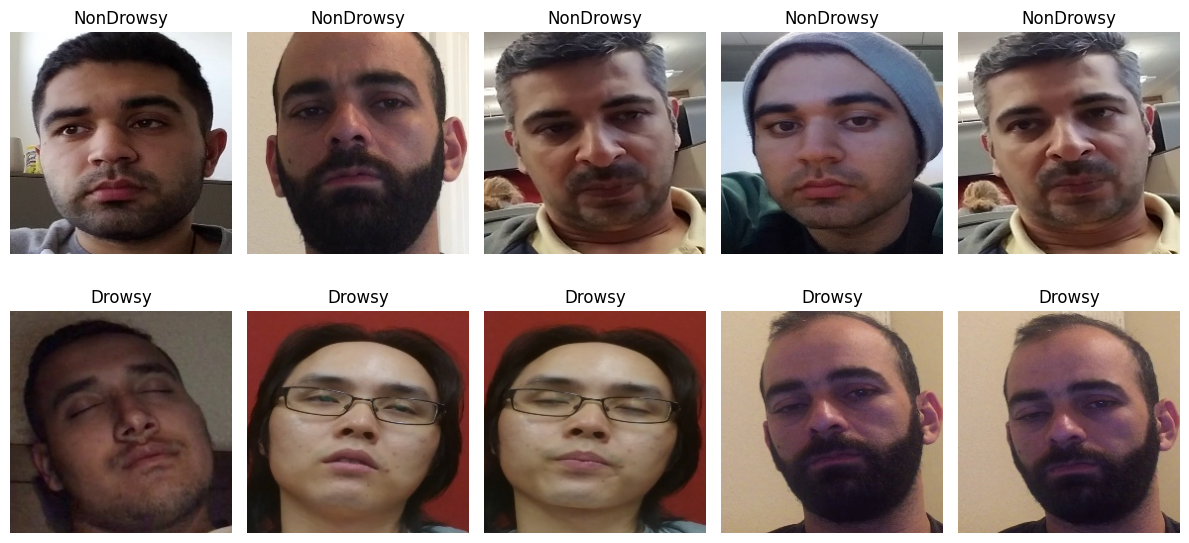

In [ ]:
# ----------------------------------------------------------
# Visualize random processed face samples (robust version)
# ----------------------------------------------------------

import random
import matplotlib.pyplot as plt
import cv2
import os

plt.figure(figsize=(12, 6))
plot_index = 1

for class_name in classes:

    class_folder = os.path.join(processed_root, class_name)

    # Filter only image files
    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Ensure we don't sample more than available
    sample_count = min(5, len(image_files))
    random_images = random.sample(image_files, sample_count)

    for img_name in random_images:
        img_path = os.path.join(class_folder, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue  # skip unreadable images

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(len(classes), 5, plot_index)
        plt.imshow(image)
        plt.title(class_name)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------
# Create train / val / test split structure
# ----------------------------------------------------------

import os
import shutil
from sklearn.model_selection import train_test_split

split_root = processed_root + "_split"

train_dir = os.path.join(split_root, "train")
val_dir   = os.path.join(split_root, "val")
test_dir  = os.path.join(split_root, "test")

for split in [train_dir, val_dir, test_dir]:
    os.makedirs(split, exist_ok=True)
    for class_name in classes:
        os.makedirs(os.path.join(split, class_name), exist_ok=True)

print("Split folders created at:")
print(split_root)

Split folders created at:
/content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset_face_224_split


In [ ]:
# ----------------------------------------------------------
# Stratified split (70 / 15 / 15)
# ----------------------------------------------------------

for class_name in classes:

    class_folder = os.path.join(processed_root, class_name)

    image_files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # First split: Train (70%) and Temp (30%)
    train_files, temp_files = train_test_split(
        image_files,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # Second split: Validation (15%) and Test (15%)
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    # Copy files
    for file in train_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(train_dir, class_name, file)
        )

    for file in val_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(val_dir, class_name, file)
        )

    for file in test_files:
        shutil.copy(
            os.path.join(class_folder, file),
            os.path.join(test_dir, class_name, file)
        )

print("Dataset split completed.")

Dataset split completed.


In [ ]:
# ----------------------------------------------------------
# Verify split distribution
# ----------------------------------------------------------

for split_name, split_path in {
    "Train": train_dir,
    "Validation": val_dir,
    "Test": test_dir
}.items():

    print(f"\n{split_name} Set:")

    for class_name in classes:
        class_path = os.path.join(split_path, class_name)
        count = len(os.listdir(class_path))
        print(f"  {class_name}: {count}")


Train Set:
  NonDrowsy: 3191
  Drowsy: 3162

Validation Set:
  NonDrowsy: 684
  Drowsy: 678

Test Set:
  NonDrowsy: 684
  Drowsy: 678


In [ ]:
# ----------------------------------------------------------
# Import required libraries
# ----------------------------------------------------------

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import os

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# ----------------------------------------------------------
# Define dataset paths
# ----------------------------------------------------------

train_path = os.path.join(split_root, "train")
val_path   = os.path.join(split_root, "val")
test_path  = os.path.join(split_root, "test")

print("Train path:", train_path)
print("Validation path:", val_path)
print("Test path:", test_path)

Train path: /content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset_face_224_split/train
Validation path: /content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset_face_224_split/val
Test path: /content/drive/MyDrive/Thesis-1/Drowsiness Prediction Dataset/DrowsinessPredictionData/data/DPDDataset_face_224_split/test


In [ ]:
# ----------------------------------------------------------
# Data Generators
# ----------------------------------------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 6353 files belonging to 2 classes.
Found 1362 files belonging to 2 classes.
Found 1362 files belonging to 2 classes.
Classes: ['Drowsy', 'NonDrowsy']


In [ ]:
# ----------------------------------------------------------
# Preprocessing for MobileNetV2 (Corrected)
# ----------------------------------------------------------

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(AUTOTUNE)

In [ ]:
# ----------------------------------------------------------
# Build MobileNetV2 Transfer Learning Model
# ----------------------------------------------------------

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze backbone
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(2, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,458 (9.87 MB)

 Trainable params: 328,962 (1.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
# ----------------------------------------------------------
# Compile Model
# ----------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# ----------------------------------------------------------
# Training Callbacks
# ----------------------------------------------------------

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [ ]:
# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6401 - loss: 0.7150

199/199 ━━━━━━━━━━━━━━━━━━━━ 426s 2s/step - accuracy: 0.6403 - loss: 0.7147 - val_accuracy: 0.7885 - val_loss: 0.6127 - learning_rate: 1.0000e-04
Epoch 2/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7531 - loss: 0.5325

199/199 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.7531 - loss: 0.5325 - val_accuracy: 0.7944 - val_loss: 0.5138 - learning_rate: 1.0000e-04
Epoch 3/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.7611 - loss: 0.5189 - val_accuracy: 0.5639 - val_loss: 0.8310 - learning_rate: 1.0000e-04
Epoch 4/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.7732 - loss: 0.4869 - val_accuracy: 0.6490 - val_loss: 0.7451 - learning_rate: 1.0000e-04
Epoch 5/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.7897 - loss: 0.4679 - val_accuracy: 0.5051 - val_loss: 1.8344 - learning_rate: 1.0000e-04
Epoch 6/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7986 - loss: 0.4508

199/199 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.7987 - loss: 0.4506 - val_accuracy: 0.8289 - val_loss: 0.3727 - learning_rate: 3.0000e-05
Epoch 7/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7995 - loss: 0.4340

199/199 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.7996 - loss: 0.4339 - val_accuracy: 0.8326 - val_loss: 0.3664 - learning_rate: 3.0000e-05
Epoch 8/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.7940 - loss: 0.4402 - val_accuracy: 0.8179 - val_loss: 0.3712 - learning_rate: 3.0000e-05
Epoch 9/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.7963 - loss: 0.4410 - val_accuracy: 0.8297 - val_loss: 0.3923 - learning_rate: 3.0000e-05
Epoch 10/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8054 - loss: 0.4296

...

199/199 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.8115 - loss: 0.4097 - val_accuracy: 0.8355 - val_loss: 0.3542 - learning_rate: 9.0000e-06
Epoch 15/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.8213 - loss: 0.4002 - val_accuracy: 0.8311 - val_loss: 0.3713 - learning_rate: 9.0000e-06
Epoch 16/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8175 - loss: 0.4022

199/199 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.8175 - loss: 0.4021 - val_accuracy: 0.8429 - val_loss: 0.3539 - learning_rate: 9.0000e-06
Epoch 17/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 357s 2s/step - accuracy: 0.8149 - loss: 0.4056 - val_accuracy: 0.8341 - val_loss: 0.3541 - learning_rate: 9.0000e-06
Epoch 18/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.8124 - loss: 0.4017 - val_accuracy: 0.8341 - val_loss: 0.3592 - learning_rate: 9.0000e-06
Epoch 19/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 347s 2s/step - accuracy: 0.8171 - loss: 0.4056 - val_accuracy: 0.8326 - val_loss: 0.3645 - learning_rate: 9.0000e-06
Epoch 20/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.8122 - loss: 0.3972 - val_accuracy: 0.8392 - val_loss: 0.3550 - learning_rate: 2.7000e-06
Epoch 21/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8191 - loss: 0.3950

199/199 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.8192 - loss: 0.3950 - val_accuracy: 0.8385 - val_loss: 0.3529 - learning_rate: 2.7000e-06
Epoch 22/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8175 - loss: 0.3970

199/199 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.8175 - loss: 0.3969 - val_accuracy: 0.8385 - val_loss: 0.3526 - learning_rate: 2.7000e-06
Epoch 23/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.8125 - loss: 0.4021 - val_accuracy: 0.8392 - val_loss: 0.3548 - learning_rate: 2.7000e-06
Epoch 24/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8103 - loss: 0.4057

199/199 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.8104 - loss: 0.4056 - val_accuracy: 0.8399 - val_loss: 0.3515 - learning_rate: 2.7000e-06
Epoch 25/25
199/199 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.8285 - loss: 0.3942 - val_accuracy: 0.8392 - val_loss: 0.3518 - learning_rate: 2.7000e-06


In [ ]:
model.save("/content/drive/MyDrive/drowsiness_model_v1.keras")

In [ ]:
import pickle
with open("/content/drive/MyDrive/history.pkl", "wb") as f:
    pickle.dump(history.history, f)